# VDP GMM vs digest2 — S3M Antisun Benchmark

Recreates the classic pure-S3M single-epoch benchmark, but with the new VDP GMM probability map result file.

- **Figure 1** (`roc_s3m_gmm_benchmark.png/pdf`): ROC curve, completeness vs contamination, for VDP GMM and digest2.
- **Figure 2** (`quadrant_s3m_gmm_benchmark.png/pdf`): Log-log score-threshold quadrant scatter.

Input parquet already contains `P_NEO_vdp` and `P_NEO_d2`; no rescoring is done in this notebook.


## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

_ROOT_CANDIDATES = [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), '..', '..')),
]
_HERE = next(
    (p for p in _ROOT_CANDIDATES if os.path.exists(os.path.join(p, 's3m_digest2_comparison_s3m_gmm.parquet'))),
    os.getcwd(),
)

## 2. Run configs

In [2]:
RUNS = [
    dict(
        label      = 's3m_gmm',
        title      = 'Pure-S3M antisun benchmark\n(new VDP GMM map)',
        parquet    = os.path.join(_HERE, 's3m_digest2_comparison_s3m_gmm.parquet'),
        panel_idx  = 0,
    ),
]

POPS   = ['NEO', 'MBA', 'TNO', 'Trojans']
COLORS = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}


## 3. ROC helpers

In [3]:
THRESHOLDS = np.linspace(0, 1, 401)

def compute_roc(scores, is_neo, thresholds):
    n_neo = is_neo.sum()
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))
    for j, t in enumerate(thresholds):
        above = scores > t
        tp = above[ is_neo].sum()
        fp = above[~is_neo].sum()
        comp[j] = tp / max(n_neo, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont

def best_f1(comp, cont, thr):
    pur = 1.0 - cont
    f1  = np.where(pur + comp > 0, 2 * pur * comp / (pur + comp + 1e-12), 0.0)
    i   = np.argmax(f1)
    return thr[i], comp[i], cont[i], f1[i]

def max_completeness_at_contamination(comp, cont, thr, contam_limit=0.10):
    """Best completeness among thresholds with nonzero selection and contamination <= limit."""
    valid = np.flatnonzero((cont <= contam_limit) & (comp > 0))
    if len(valid) == 0:
        return np.nan, np.nan, np.nan
    max_comp = comp[valid].max()
    tied = valid[np.isclose(comp[valid], max_comp)]
    i = tied[np.argmin(cont[tied])]
    return thr[i], comp[i], cont[i]

def min_contamination_at_completeness(comp, cont, thr, comp_target=0.70):
    """Lowest contamination among thresholds with completeness >= target."""
    valid = np.flatnonzero(comp >= comp_target)
    if len(valid) == 0:
        return np.nan, np.nan, np.nan
    min_cont = cont[valid].min()
    tied = valid[np.isclose(cont[valid], min_cont)]
    i = tied[np.argmax(comp[tied])]
    return thr[i], comp[i], cont[i]

## 4. Load data and compute ROC for each direction

In [4]:
for run in RUNS:
    df = pd.read_parquet(run['parquet'])
    is_neo = (df['true_population'] == 'NEO').to_numpy()
    n_neo  = is_neo.sum()

    comp_v, cont_v = compute_roc(df['P_NEO_vdp'].to_numpy(), is_neo, THRESHOLDS)
    comp_d, cont_d = compute_roc(df['P_NEO_d2'].to_numpy(),  is_neo, THRESHOLDS)

    tv, cv, nv, fv = best_f1(comp_v, cont_v, THRESHOLDS)
    td, cd, nd, fd = best_f1(comp_d, cont_d, THRESHOLDS)

    run.update(dict(
        df=df, is_neo=is_neo, n_neo=n_neo,
        comp_v=comp_v, cont_v=cont_v,
        comp_d=comp_d, cont_d=cont_d,
        tv=tv, cv=cv, nv=nv, fv=fv,
        td=td, cd=cd, nd=nd, fd=fd,
    ))

    print(f"{run['label']}:  N_NEO={n_neo}  "
          f"VDP F1={fv:.3f} (comp={cv:.1%}, cont={nv:.1%}, t={tv:.3f})  "
          f"d2 F1={fd:.3f} (comp={cd:.1%}, cont={nd:.1%}, t={td:.3f})")

# Fiducial operating-point diagnostics suggested for the paper text/table.
# C@contam<=10% means maximum NEO completeness at any threshold with contamination <= 10%.
# contam@C>=70% means minimum contamination at any threshold with NEO completeness >= 70%.
fiducial_rows = []
for run in RUNS:
    for method, comp_key, cont_key, t_key, c_key, n_key, f_key in [
        ('VDP',     'comp_v', 'cont_v', 'tv', 'cv', 'nv', 'fv'),
        ('digest2', 'comp_d', 'cont_d', 'td', 'cd', 'nd', 'fd'),
    ]:
        t10, c10, n10 = max_completeness_at_contamination(
            run[comp_key], run[cont_key], THRESHOLDS, contam_limit=0.10
        )
        t70, c70, n70 = min_contamination_at_completeness(
            run[comp_key], run[cont_key], THRESHOLDS, comp_target=0.70
        )
        fiducial_rows.append(dict(
            field=run['title'].replace('\n', ' '),
            method=method,
            N_total=len(run['df']),
            N_NEO=int(run['n_neo']),
            best_F1_threshold=run[t_key],
            best_F1=run[f_key],
            best_F1_completeness=run[c_key],
            best_F1_contamination=run[n_key],
            threshold_for_contam_le_10=t10,
            completeness_at_contam_le_10=c10,
            contamination_at_that_threshold=n10,
            threshold_for_comp_ge_70=t70,
            completeness_at_that_threshold=c70,
            contamination_at_comp_ge_70=n70,
        ))

fiducial_metrics = pd.DataFrame(fiducial_rows)

fiducial_metrics_display = fiducial_metrics.copy()
percent_cols = [
    'best_F1_completeness', 'best_F1_contamination',
    'completeness_at_contam_le_10', 'contamination_at_that_threshold',
    'completeness_at_that_threshold', 'contamination_at_comp_ge_70',
]
threshold_cols = ['best_F1_threshold', 'threshold_for_contam_le_10', 'threshold_for_comp_ge_70']
for col in percent_cols:
    fiducial_metrics_display[col] = fiducial_metrics_display[col].map(
        lambda x: 'not reached' if pd.isna(x) else f'{100*x:.1f}%'
    )
for col in threshold_cols:
    fiducial_metrics_display[col] = fiducial_metrics_display[col].map(
        lambda x: 'not reached' if pd.isna(x) else f'{x:.3f}'
    )
fiducial_metrics_display['best_F1'] = fiducial_metrics_display['best_F1'].map(lambda x: f'{x:.3f}')

display(fiducial_metrics_display)

s3m_gmm:  N_NEO=1454  VDP F1=0.823 (comp=71.0%, cont=2.1%, t=0.468)  d2 F1=0.685 (comp=54.5%, cont=8.0%, t=0.970)


,field,method,N_total,N_NEO,best_F1_threshold,best_F1,best_F1_completeness,best_F1_contamination,threshold_for_contam_le_10,completeness_at_contam_le_10,contamination_at_that_threshold,threshold_for_comp_ge_70,completeness_at_that_threshold,contamination_at_comp_ge_70
0,Pure-S3M antisun benchmark (new VDP GMM map),VDP,20059,1454,0.468,0.823,71.0%,2.1%,0.258,72.0%,8.3%,0.535,70.4%,1.8%
1,Pure-S3M antisun benchmark (new VDP GMM map),digest2,20059,1454,0.970,0.685,54.5%,8.0%,0.970,54.5%,8.0%,0.620,70.2%,82.1%


## 5. Figure 1: ROC curves — 2×2 panel

Each panel: completeness vs contamination for VDP and digest2, with best-F1 operating points annotated.

Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/roc_s3m_gmm_benchmark.png
Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/roc_s3m_gmm_benchmark.pdf


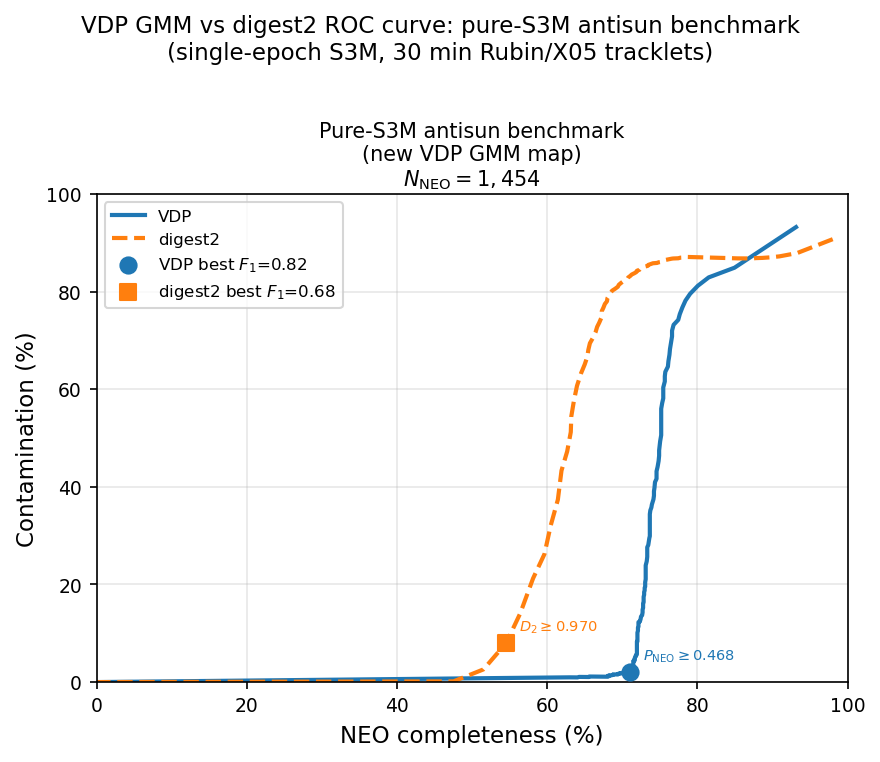

In [5]:
n_panels = len(RUNS)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).flatten()

for run in RUNS:
    ax = axes_flat[run['panel_idx']]
    row, col = divmod(run['panel_idx'], 2)

    ax.plot(run['comp_v'] * 100, run['cont_v'] * 100,
            lw=2.0, color='tab:blue', label='VDP')
    ax.plot(run['comp_d'] * 100, run['cont_d'] * 100,
            lw=2.0, color='tab:orange', linestyle='--', label='digest2')

    ax.scatter([run['cv'] * 100], [run['nv'] * 100],
               color='tab:blue', s=60, zorder=5,
               label=f"VDP best $F_1$={run['fv']:.2f}")
    ax.scatter([run['cd'] * 100], [run['nd'] * 100],
               color='tab:orange', s=60, zorder=5, marker='s',
               label=f"digest2 best $F_1$={run['fd']:.2f}")

    # Annotate best-F1 thresholds
    ax.annotate(
        f'$P_{{\\mathrm{{NEO}}}}\\geq{run["tv"]:.3f}$',
        xy=(run['cv'] * 100, run['nv'] * 100),
        xytext=(6, 6), textcoords='offset points',
        color='tab:blue', fontsize=7,
    )
    ax.annotate(
        f'$D_2\\geq{run["td"]:.3f}$',
        xy=(run['cd'] * 100, run['nd'] * 100),
        xytext=(6, 6), textcoords='offset points',
        color='tab:orange', fontsize=7,
    )

    ax.set_title(f"{run['title']}\n$N_{{\\mathrm{{NEO}}}}={run['n_neo']:,}$", pad=4)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)

    # Axis labels: bottom row and left column only
    if n_panels == 1 or row == 1:
        ax.set_xlabel('NEO completeness (%)')
    if col == 0:
        ax.set_ylabel('Contamination (%)')

    # Shared legend on first panel only
    if run['panel_idx'] == 0:
        ax.legend(loc='upper left', frameon=True)

fig.suptitle(
    'VDP GMM vs digest2 ROC curve: pure-S3M antisun benchmark\n'
    '(single-epoch S3M, 30 min Rubin/X05 tracklets)',
    fontsize=11, y=1.01,
)
plt.tight_layout()

fig_out_roc_png = os.path.join(_HERE, 'roc_s3m_gmm_benchmark.png')
fig_out_roc_pdf = os.path.join(_HERE, 'roc_s3m_gmm_benchmark.pdf')
fig.savefig(fig_out_roc_png)
fig.savefig(fig_out_roc_pdf)
print(f'Saved: {fig_out_roc_png}')
print(f'Saved: {fig_out_roc_pdf}')
plt.show()
plt.close(fig)

## 6. Figure 2: Score-threshold quadrants — 2×2 panel

Log-log population-visible view. NEOs plotted first (underneath); non-NEO populations on top. Score floor = 1e-4 so near-zero scores stack on the floor axis instead of disappearing.

Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/quadrant_s3m_gmm_benchmark.png
Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/quadrant_s3m_gmm_benchmark.pdf


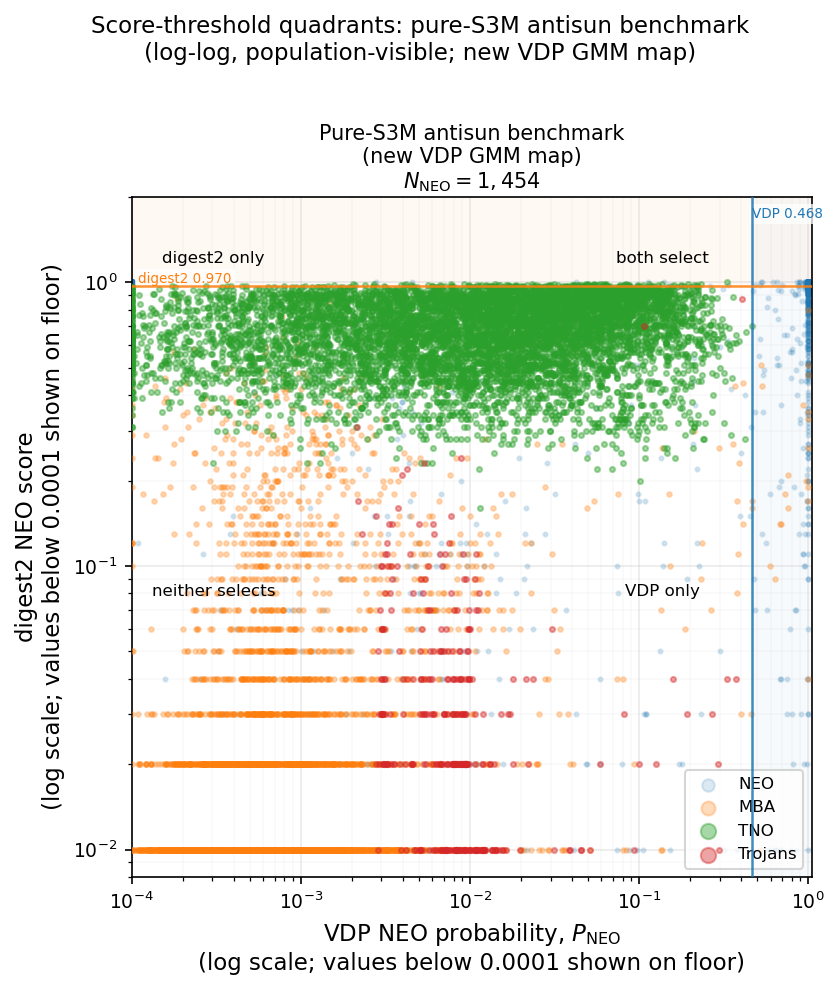

In [6]:
SCORE_FLOOR = 1e-4
Y_LOW       = 8e-3
X_HIGH      = 1.05
Y_HIGH      = 2.0

PLOT_STYLE = {
    'NEO':     dict(s=4,  alpha=0.16, zorder=2),
    'MBA':     dict(s=5,  alpha=0.28, zorder=3),
    'TNO':     dict(s=6,  alpha=0.42, zorder=5),
    'Trojans': dict(s=6,  alpha=0.42, zorder=6),
}

from matplotlib.transforms import blended_transform_factory

n_panels = len(RUNS)
fig, axes = plt.subplots(1, n_panels, figsize=(6.5 * n_panels, 6.5))
axes_flat = np.atleast_1d(axes).flatten()

for run in RUNS:
    ax  = axes_flat[run['panel_idx']]
    row, col = divmod(run['panel_idx'], 2)
    df  = run['df']
    tv  = run['tv']
    td  = run['td']

    x_vis = np.clip(df['P_NEO_vdp'].to_numpy(), SCORE_FLOOR, 1.0)
    y_vis = np.clip(df['P_NEO_d2'].to_numpy(),  SCORE_FLOOR, 1.0)

    for pop in ['NEO', 'MBA', 'TNO', 'Trojans']:
        if pop not in df['true_population'].values:
            continue
        mask = (df['true_population'] == pop).to_numpy()
        ax.scatter(
            x_vis[mask], y_vis[mask],
            label=pop,
            color=COLORS[pop],
            rasterized=True,
            **PLOT_STYLE[pop],
        )

    ax.axvline(tv, color='tab:blue',   lw=1.2, alpha=0.85, zorder=8)
    ax.axhline(td, color='tab:orange', lw=1.2, alpha=0.85, zorder=8)
    ax.axvspan(tv, X_HIGH, color='tab:blue',   alpha=0.03, zorder=0)
    ax.axhspan(td, Y_HIGH, color='tab:orange', alpha=0.045, zorder=0)

    _bbox = dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5)

    # VDP vertical line: label at the TOP of the line, just to its right.
    # Blended: x tracks the line in data/log coords, y pinned to top of axes.
    _tx = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(tv, 0.985, f'VDP {tv:.3f}',
            transform=_tx, color='tab:blue', fontsize=6.5,
            ha='left', va='top', bbox=_bbox)

    # digest2 horizontal line: label at the LEFT edge of the axes, just above
    # the line. Blended: x pinned to left edge of axes, y tracks line in data.
    _ty = blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(0.01, td, f'digest2 {td:.3f}',
            transform=_ty, color='tab:orange', fontsize=6.5,
            ha='left', va='bottom', bbox=_bbox)

    # Quadrant labels — mid-panel positions, clear of threshold annotations
    ax.text(0.78, 0.92, 'both select',     transform=ax.transAxes, fontsize=8, ha='center', va='top')
    ax.text(0.78, 0.42, 'VDP only',        transform=ax.transAxes, fontsize=8, ha='center', va='center')
    ax.text(0.12, 0.92, 'digest2 only',    transform=ax.transAxes, fontsize=8, ha='center', va='top')
    ax.text(0.12, 0.42, 'neither selects', transform=ax.transAxes, fontsize=8, ha='center', va='center')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(SCORE_FLOOR, X_HIGH)
    ax.set_ylim(Y_LOW, Y_HIGH)
    ax.set_box_aspect(1)
    ax.set_title(f"{run['title']}\n$N_{{\\mathrm{{NEO}}}}={run['n_neo']:,}$", pad=4)
    ax.grid(alpha=0.25, which='major')
    ax.grid(alpha=0.07, which='minor')

    if n_panels == 1 or row == 1:
        ax.set_xlabel(
            f'VDP NEO probability, $P_{{\\mathrm{{NEO}}}}$\n'
            f'(log scale; values below {SCORE_FLOOR:g} shown on floor)'
        )
    if col == 0:
        ax.set_ylabel(
            f'digest2 NEO score\n'
            f'(log scale; values below {SCORE_FLOOR:g} shown on floor)'
        )

    if run['panel_idx'] == 0:
        ax.legend(loc='lower right', frameon=True, markerscale=3)

fig.suptitle(
    'Score-threshold quadrants: pure-S3M antisun benchmark\n'
    '(log-log, population-visible; new VDP GMM map)',
    fontsize=11, y=1.01,
)
plt.tight_layout()

fig_out_quad_png = os.path.join(_HERE, 'quadrant_s3m_gmm_benchmark.png')
fig_out_quad_pdf = os.path.join(_HERE, 'quadrant_s3m_gmm_benchmark.pdf')
fig.savefig(fig_out_quad_png)
fig.savefig(fig_out_quad_pdf)
print(f'Saved: {fig_out_quad_png}')
print(f'Saved: {fig_out_quad_pdf}')
plt.show()
plt.close(fig)